K-Means Clustering

🎯 Objective
To implement the K-Means clustering algorithm on:

1.)A synthetic dataset (Part A)

2.)Handwritten digit dataset (Part B)

📘 THEORY: What is K-Means Clustering?


🔹 What is Clustering?

Clustering is an unsupervised learning technique where:

->Data has no labels

->The algorithm groups similar data points together

🔹 What is K-Means?

K-Means is an iterative clustering algorithm that:

->hooses K cluster centers (centroids)

->Assigns each data point to the nearest centroid

->Recalculates centroids as the mean of assigned points

->Repeats until convergence

🔹 Key Terms
| Term         | Meaning                                           |
| ------------ | ------------------------------------------------- |
| **K**        | Number of clusters                                |
| **Centroid** | Center of a cluster                               |
| **Inertia**  | Sum of squared distances from points to centroids |
| **Labels**   | Cluster assigned to each point                    |

🔹 Distance Used

👉 Euclidean Distance
	​


🧪 PART A: K-Means on Synthetic Dataset

📌 Step 1: Import Libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

📌 Step 2: Create Dataset



100 data points

3 clusters

2D features (easy to visualize)

In [ ]:
X, _ = make_blobs(
    n_samples=100,
    centers=3,
    n_features=2,
    cluster_std=0.2,
    random_state=0
)

📌 Step 3: Visualize Dataset

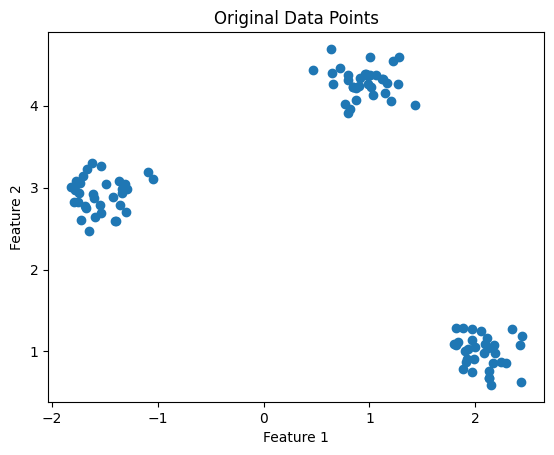

In [ ]:
plt.scatter(X[:, 0], X[:, 1])
plt.title("Original Data Points")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


📌 Step 4: Apply K-Means

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=0)
kmeans.fit(X)


KMeans(n_clusters=3, random_state=0)

📌 Step 5: Get Cluster Info

In [ ]:
centroids = kmeans.cluster_centers_
labels = kmeans.labels_

print("Centroids:\n", centroids)
print("Labels:\n", labels)


Centroids:
 [[-1.538563    2.91165191]
 [ 2.0720792   0.98848385]
 [ 0.95164831  4.28882085]]
Labels:
 [1 2 1 2 2 2 0 0 1 2 2 2 1 2 0 1 0 2 0 0 0 0 0 2 1 1 1 1 0 0 2 1 1 2 0 0 2
 1 1 0 0 1 1 2 2 2 1 1 0 0 0 1 2 1 0 0 1 1 2 1 1 0 0 0 0 1 2 0 1 2 0 2 2 1
 1 2 2 2 0 1 2 2 1 2 1 2 2 2 1 2 1 1 0 0 0 0 2 2 0 0]


📌 Step 6: Plot Clusters

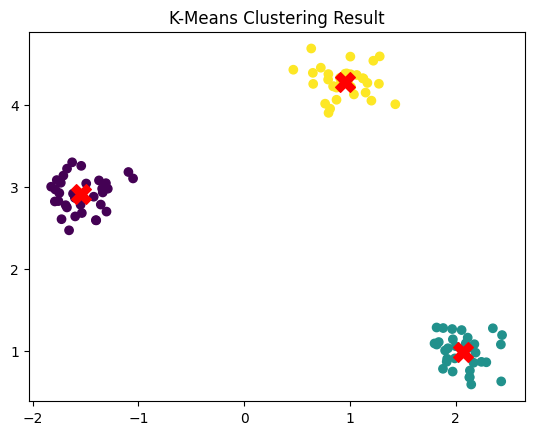

In [ ]:
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis')
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=200, marker='X')
plt.title("K-Means Clustering Result")
plt.show()


📌 Step 7: Silhouette Score

Range: -1 to +1

Higher value → better clustering

In [ ]:
score = silhouette_score(X, labels)
print("Silhouette Score:", score)


Silhouette Score: 0.8816040239688525


📌 Step 8: Elbow Method

Best K is where the curve bends (elbow point).

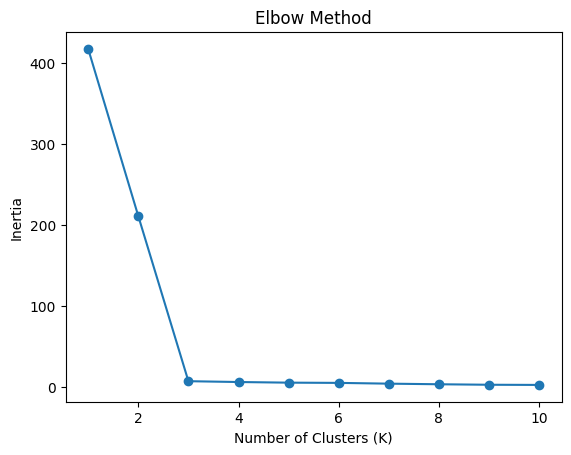

In [ ]:
inertia = []

for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=0)
    km.fit(X)
    inertia.append(km.inertia_)

plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()


🧪 PART B: Handwritten Digit Recognition using K-Means

📘 Concept

Dataset contains 8×8 images of digits (0–9)

Each image is flattened to 64 features

K-Means groups images into 10 clusters

⚠️ This is unsupervised, but we compare clusters with true labels.

📌 Step 1: Import Libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_digits
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, confusion_matrix
from scipy.stats import mode


📌 Step 2: Load Dataset

In [ ]:
digits = load_digits()

X = digits.data
y = digits.target

print(X.shape)  # (1797, 64)


(1797, 64)


📌 Step 3: Apply K-Means

In [ ]:
k_means = KMeans(n_clusters=10, random_state=0)
clusters = k_means.fit_predict(X)


📌 Step 4: Visualize Cluster Centers

Each image represents average digit shape of a cluster.

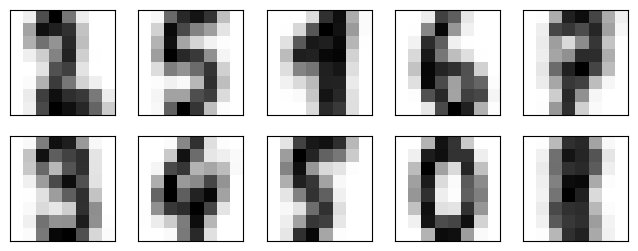

In [ ]:
fig, ax = plt.subplots(2, 5, figsize=(8, 3))

centers = k_means.cluster_centers_.reshape(10, 8, 8)

for axi, center in zip(ax.flat, centers):
    axi.set(xticks=[], yticks=[])
    axi.imshow(center, cmap=plt.cm.binary)

plt.show()


📌 Step 5: Map Clusters to True Labels

In [ ]:
labels = np.zeros_like(clusters)

for i in range(10):
    mask = (clusters == i)
    labels[mask] = mode(y[mask])[0]

📌 Step 6: Accuracy

In [ ]:
accuracy = accuracy_score(y, labels)
print("Accuracy:", accuracy)


Accuracy: 0.7440178074568725


📌 Step 7: Confusion Matrix

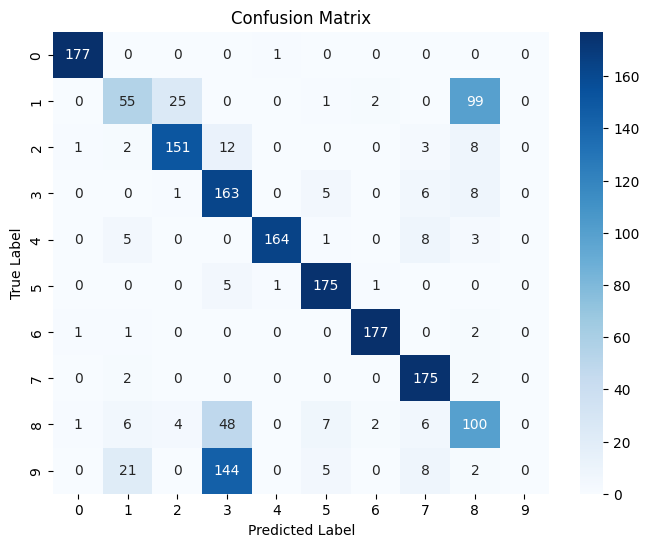

In [ ]:
cm = confusion_matrix(y, labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


📌 Step 8: Silhouette Score

In [ ]:
sil_score = silhouette_score(X, clusters)
print("Silhouette Score:", sil_score)


Silhouette Score: 0.18555026309037873
